# Heart Disease Risk Classifier — EDA Walkthrough

This notebook is a narrative walkthrough of the exploratory data analysis. It is a **thin wrapper** over the tested pipeline in `src/` and `data/` — every cell below calls the same functions used by `python data/download_data.py`, `python src/data/preprocess.py`, and `python src/eda.py` (and covered by `tests/test_data.py`), rather than duplicating that logic here. That keeps this notebook safe to re-run top-to-bottom without diverging from the pipeline the CI/CD workflow actually exercises.

Dataset: [UCI Heart Disease (Cleveland)](https://archive.ics.uci.edu/dataset/45/heart+disease), id=45 — 303 patients, 13 features, binary target (presence/absence of heart disease).

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from IPython.display import Image, display

from data.download_data import download
from src.data.preprocess import clean, load_raw
from src.eda import (
    plot_categorical_counts,
    plot_class_balance,
    plot_continuous_histograms,
    plot_correlation_heatmap,
    plot_feature_relationships,
    plot_missing_values,
)

FIGURES_DIR = ROOT / "report" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

## 1. Download and clean the data

`download()` fetches the raw UCI dataset via `ucimlrepo`; `clean()` handles the one real data-quality issue (a handful of missing `ca`/`thal` values) and binarizes the 5-class target. Both are idempotent — re-running this cell just re-produces the same committed `data/raw/` and `data/processed/` files.

In [2]:
raw_df = download()
df = clean(raw_df)
print(f"Raw: {raw_df.shape}, Cleaned: {df.shape}")
df.head()

2026-07-11 18:08:58,148 [INFO] Fetching UCI Heart Disease dataset (id=45)...


2026-07-11 18:08:59,865 [INFO] Saved 303 rows x 14 cols to /home/krishna/learning/mlops-assignment-1/data/raw/heart_disease.csv


2026-07-11 18:08:59,867 [INFO] Missing values found:
ca      4
thal    2


2026-07-11 18:08:59,868 [INFO] Dropped 6/303 rows with missing values (2.0%)


Raw: (303, 14), Cleaned: (297, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0,6,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3,3,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2,7,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0,3,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0,3,0


## 2. Missing value analysis

Run against the *raw*, pre-cleaning data — the cleaned frame above has none left by construction.

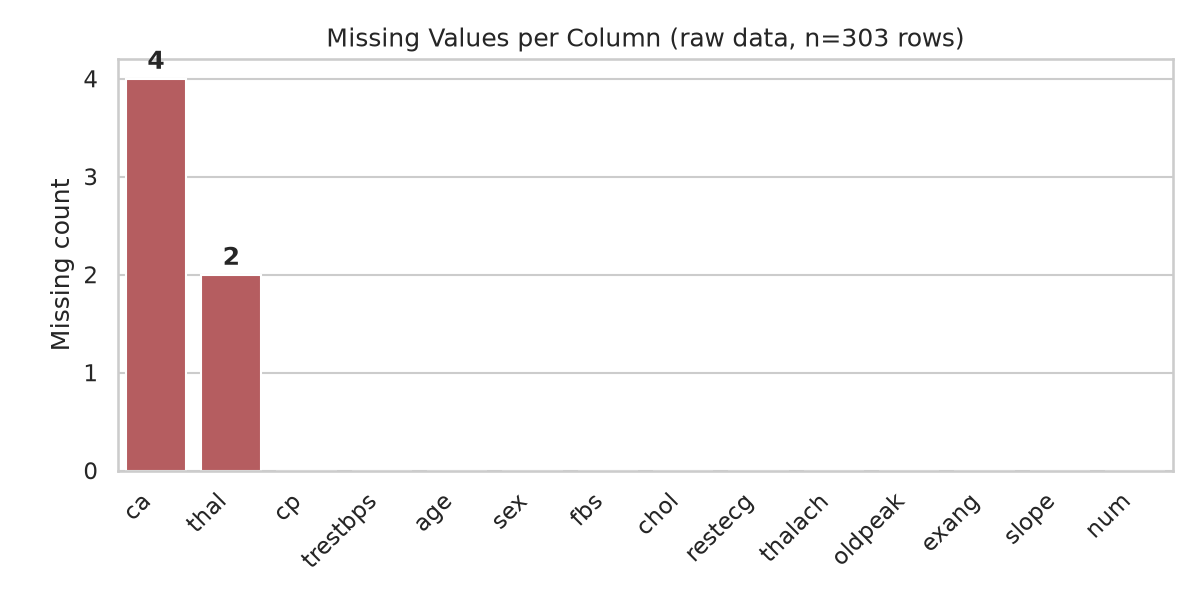

In [3]:
plot_missing_values(raw_df, FIGURES_DIR)
display(Image(filename=FIGURES_DIR / "missing_values.png"))

Only `ca` (4 missing) and `thal` (2 missing) carry any missing values — about 2% of rows, dropped rather than imputed (see `src/data/preprocess.py` for the reasoning).

## 3. Class balance

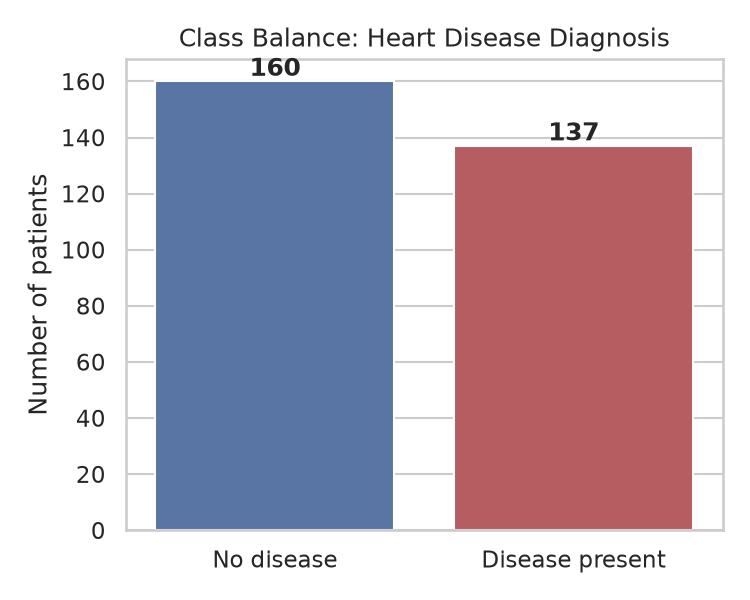

target
0    0.538721
1    0.461279
Name: proportion, dtype: float64

In [4]:
plot_class_balance(df, FIGURES_DIR)
display(Image(filename=FIGURES_DIR / "class_balance.png"))
df["target"].value_counts(normalize=True).rename("proportion")

160 "no disease" vs. 137 "disease present" — close enough to balanced that no resampling was applied.

## 4. Continuous feature distributions by diagnosis

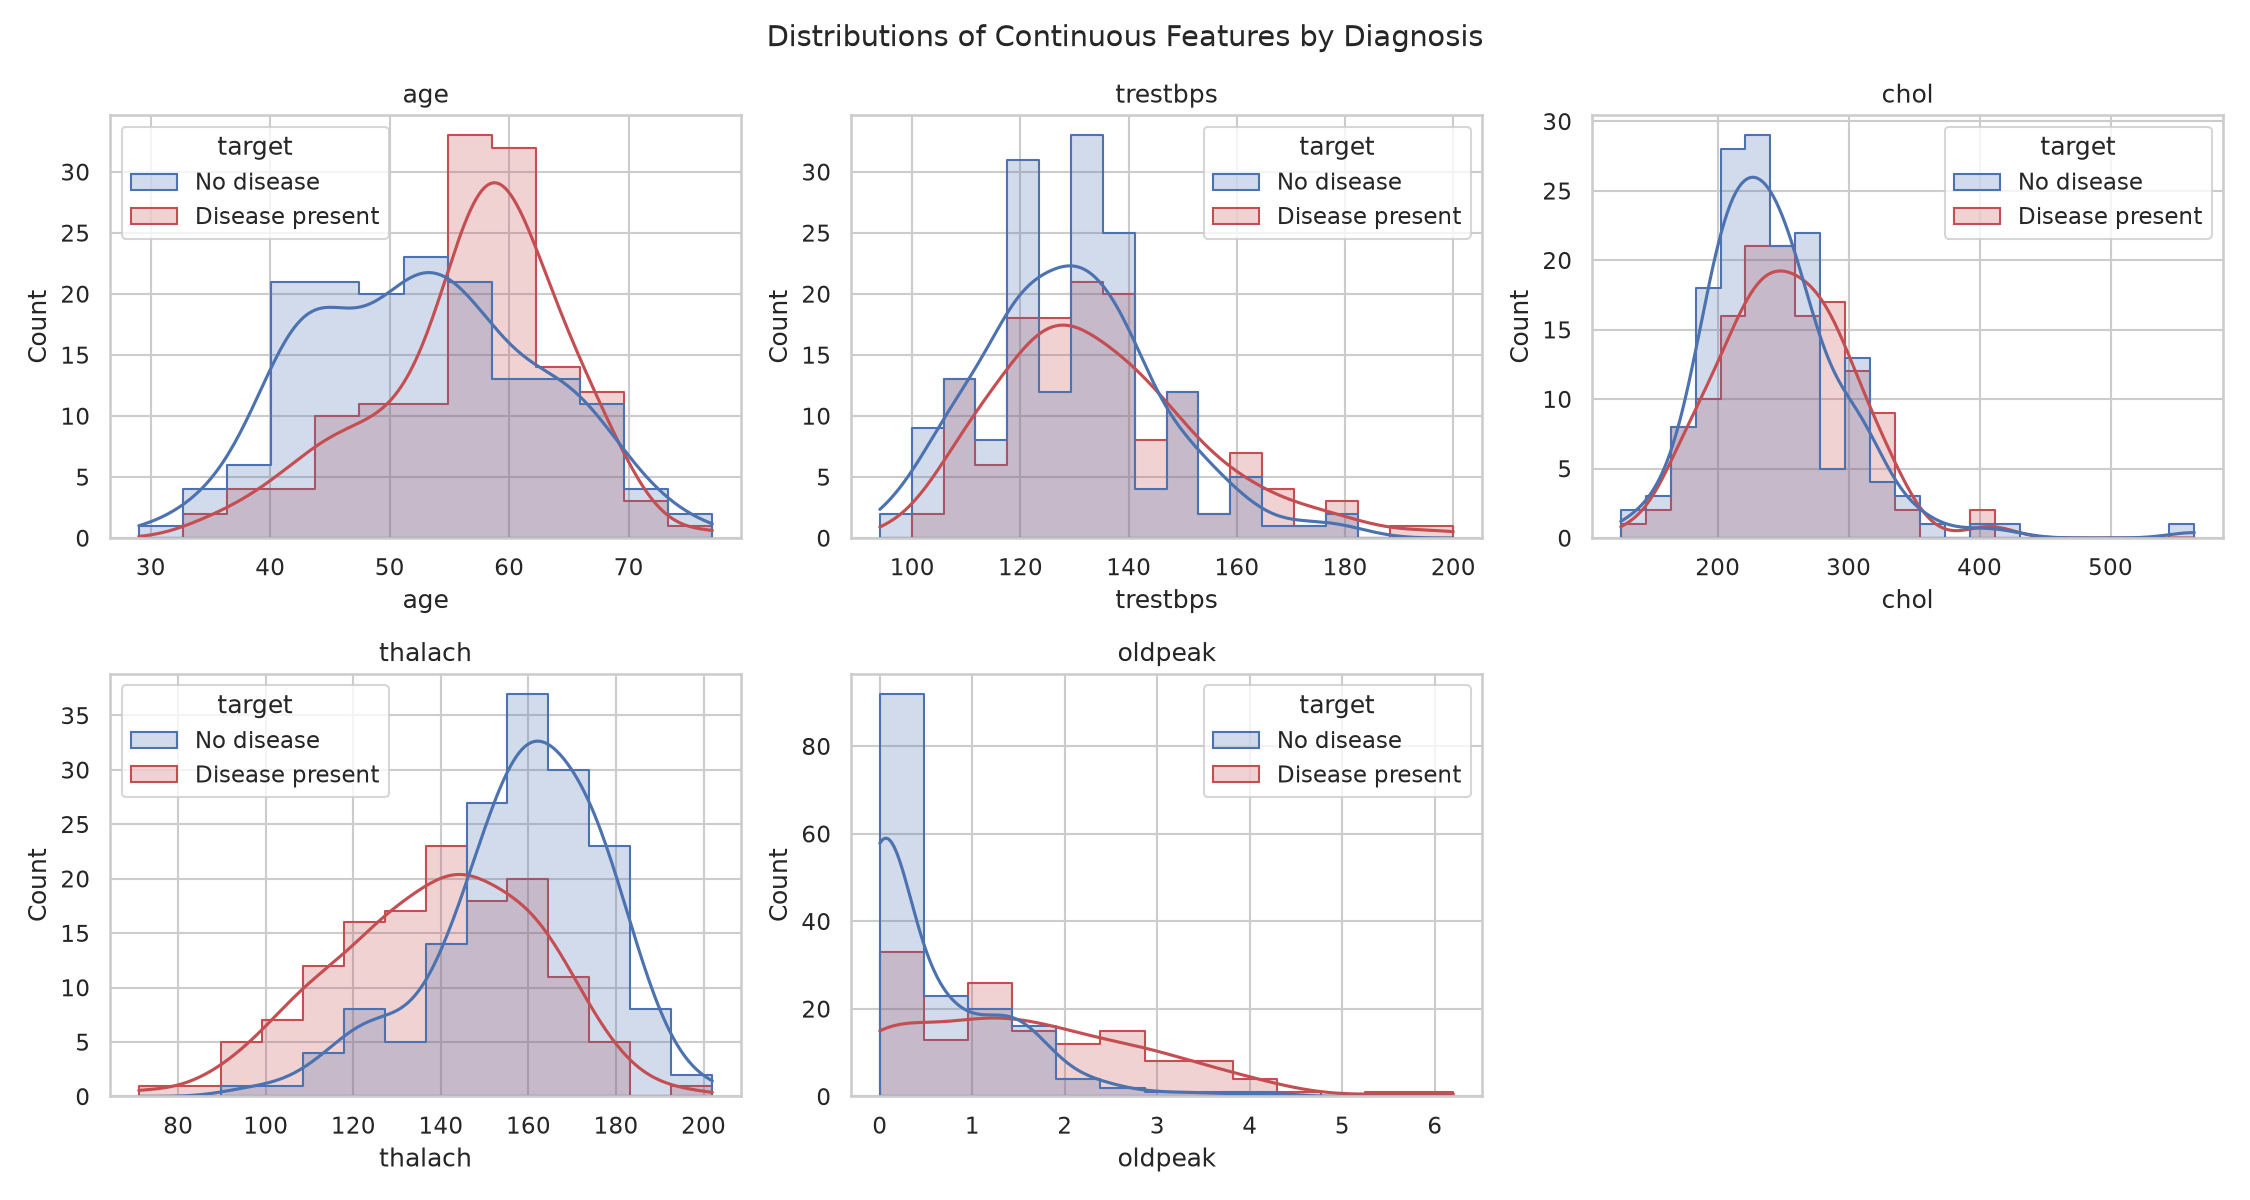

In [5]:
plot_continuous_histograms(df, FIGURES_DIR)
display(Image(filename=FIGURES_DIR / "continuous_histograms.png"))

`thalach` (max heart rate) is visibly lower, and `oldpeak` (ST depression) visibly higher, in disease-present patients — both plausible clinical signals.

## 5. Categorical feature counts by diagnosis

2026-07-11 18:09:01,135 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-07-11 18:09:01,139 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-07-11 18:09:01,165 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-07-11 18:09:01,169 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-07-11 18:09:01,198 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


...

2026-07-11 18:09:01,291 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-07-11 18:09:01,318 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-07-11 18:09:01,321 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-07-11 18:09:01,350 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-07-11 18:09:01,353 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


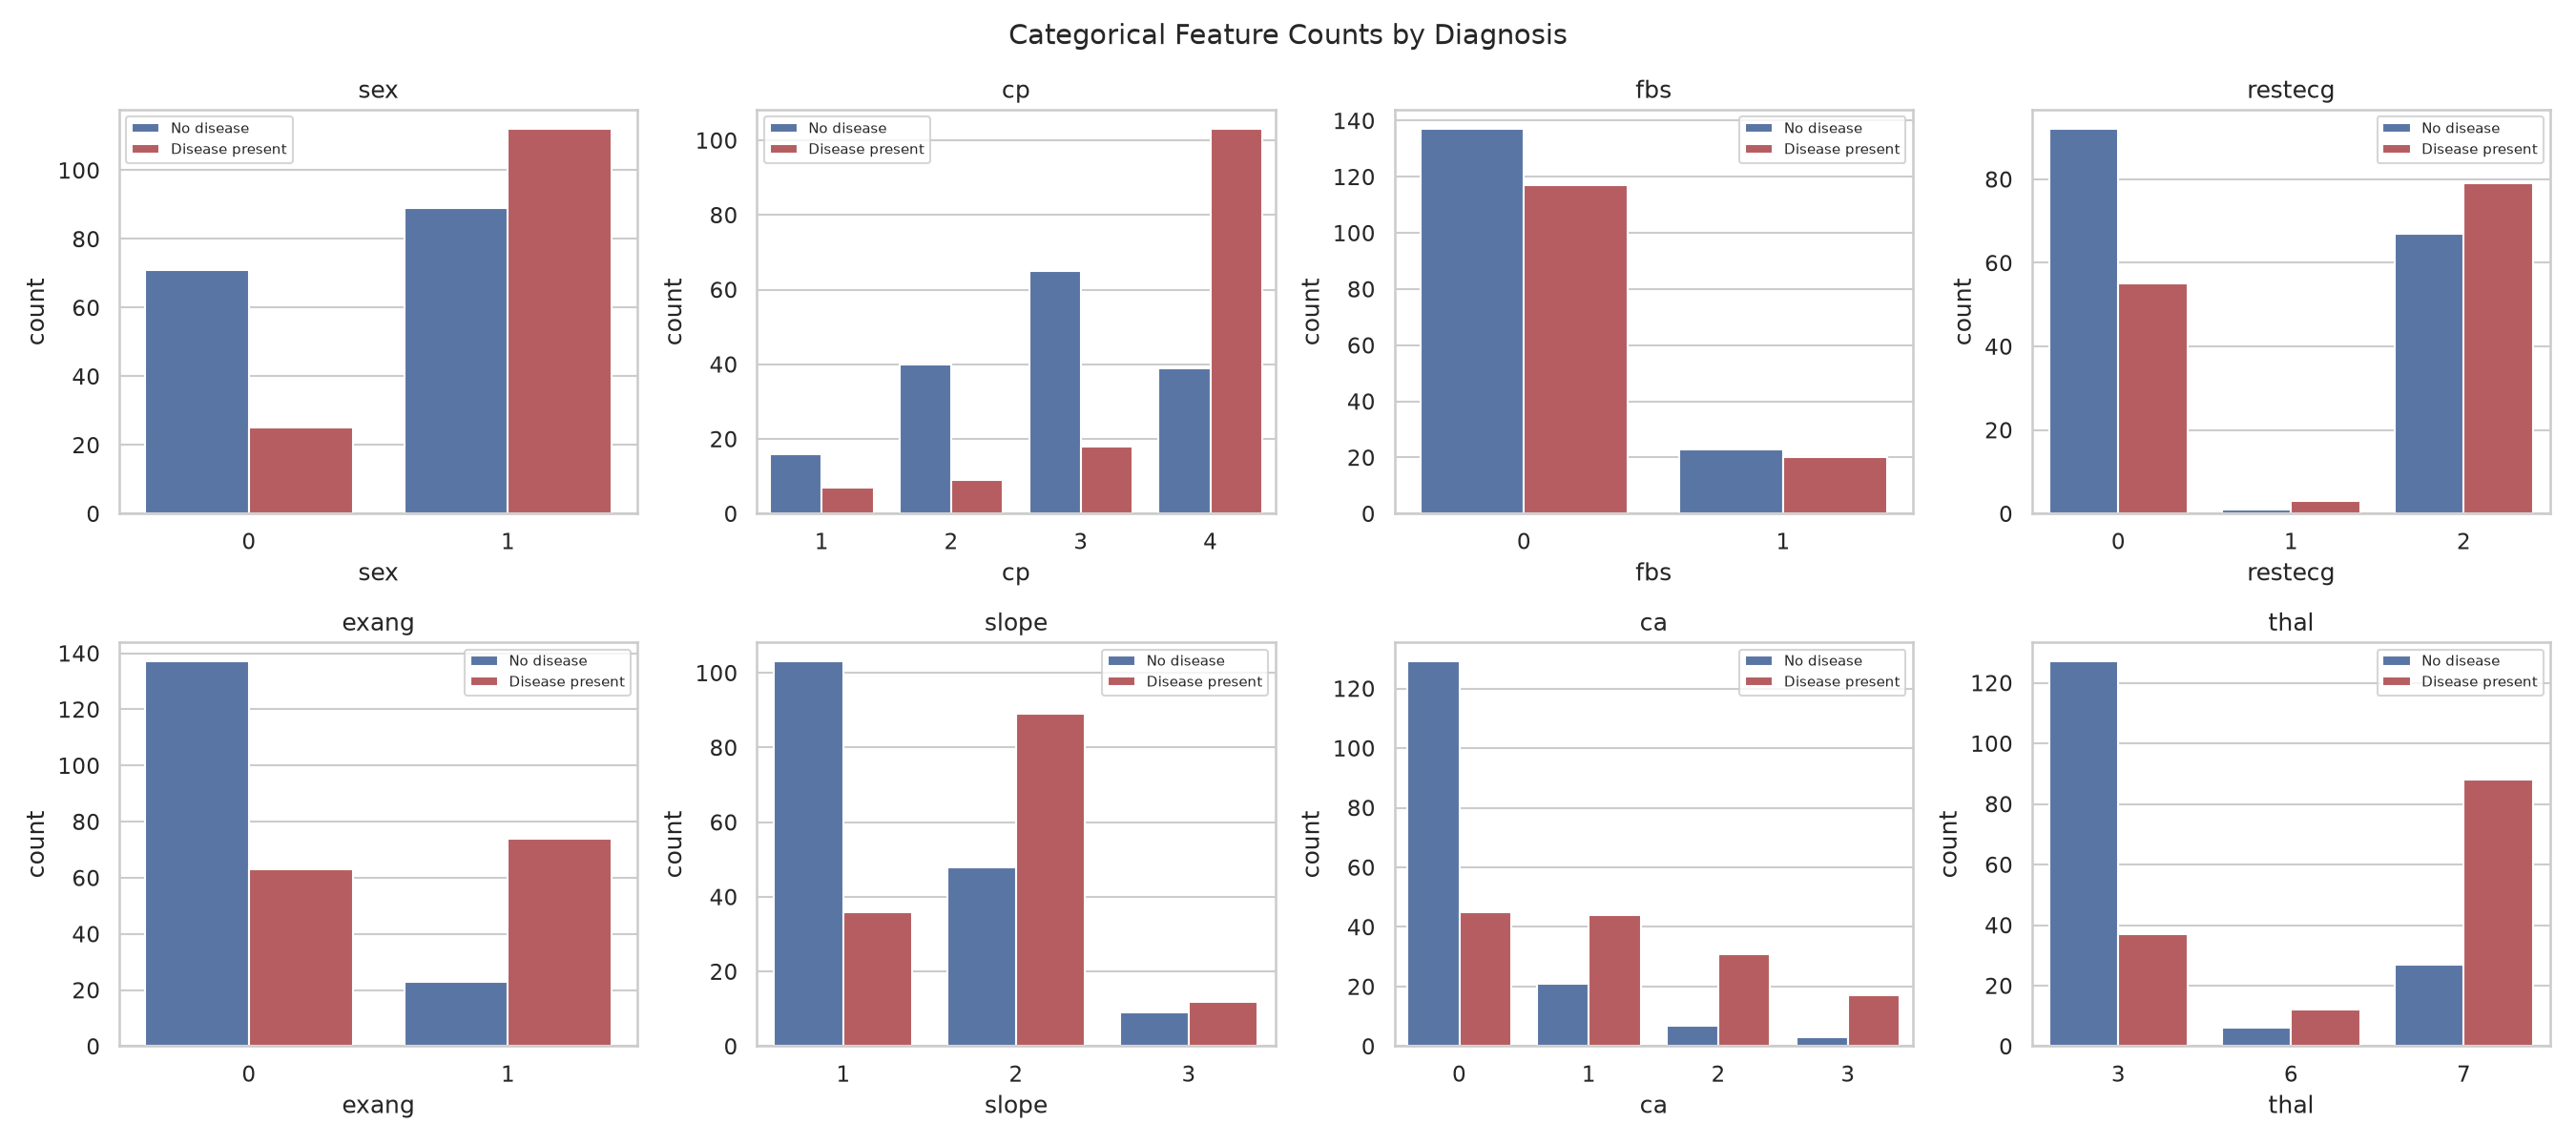

In [6]:
plot_categorical_counts(df, FIGURES_DIR)
display(Image(filename=FIGURES_DIR / "categorical_counts.png"))

## 6. Correlation heatmap

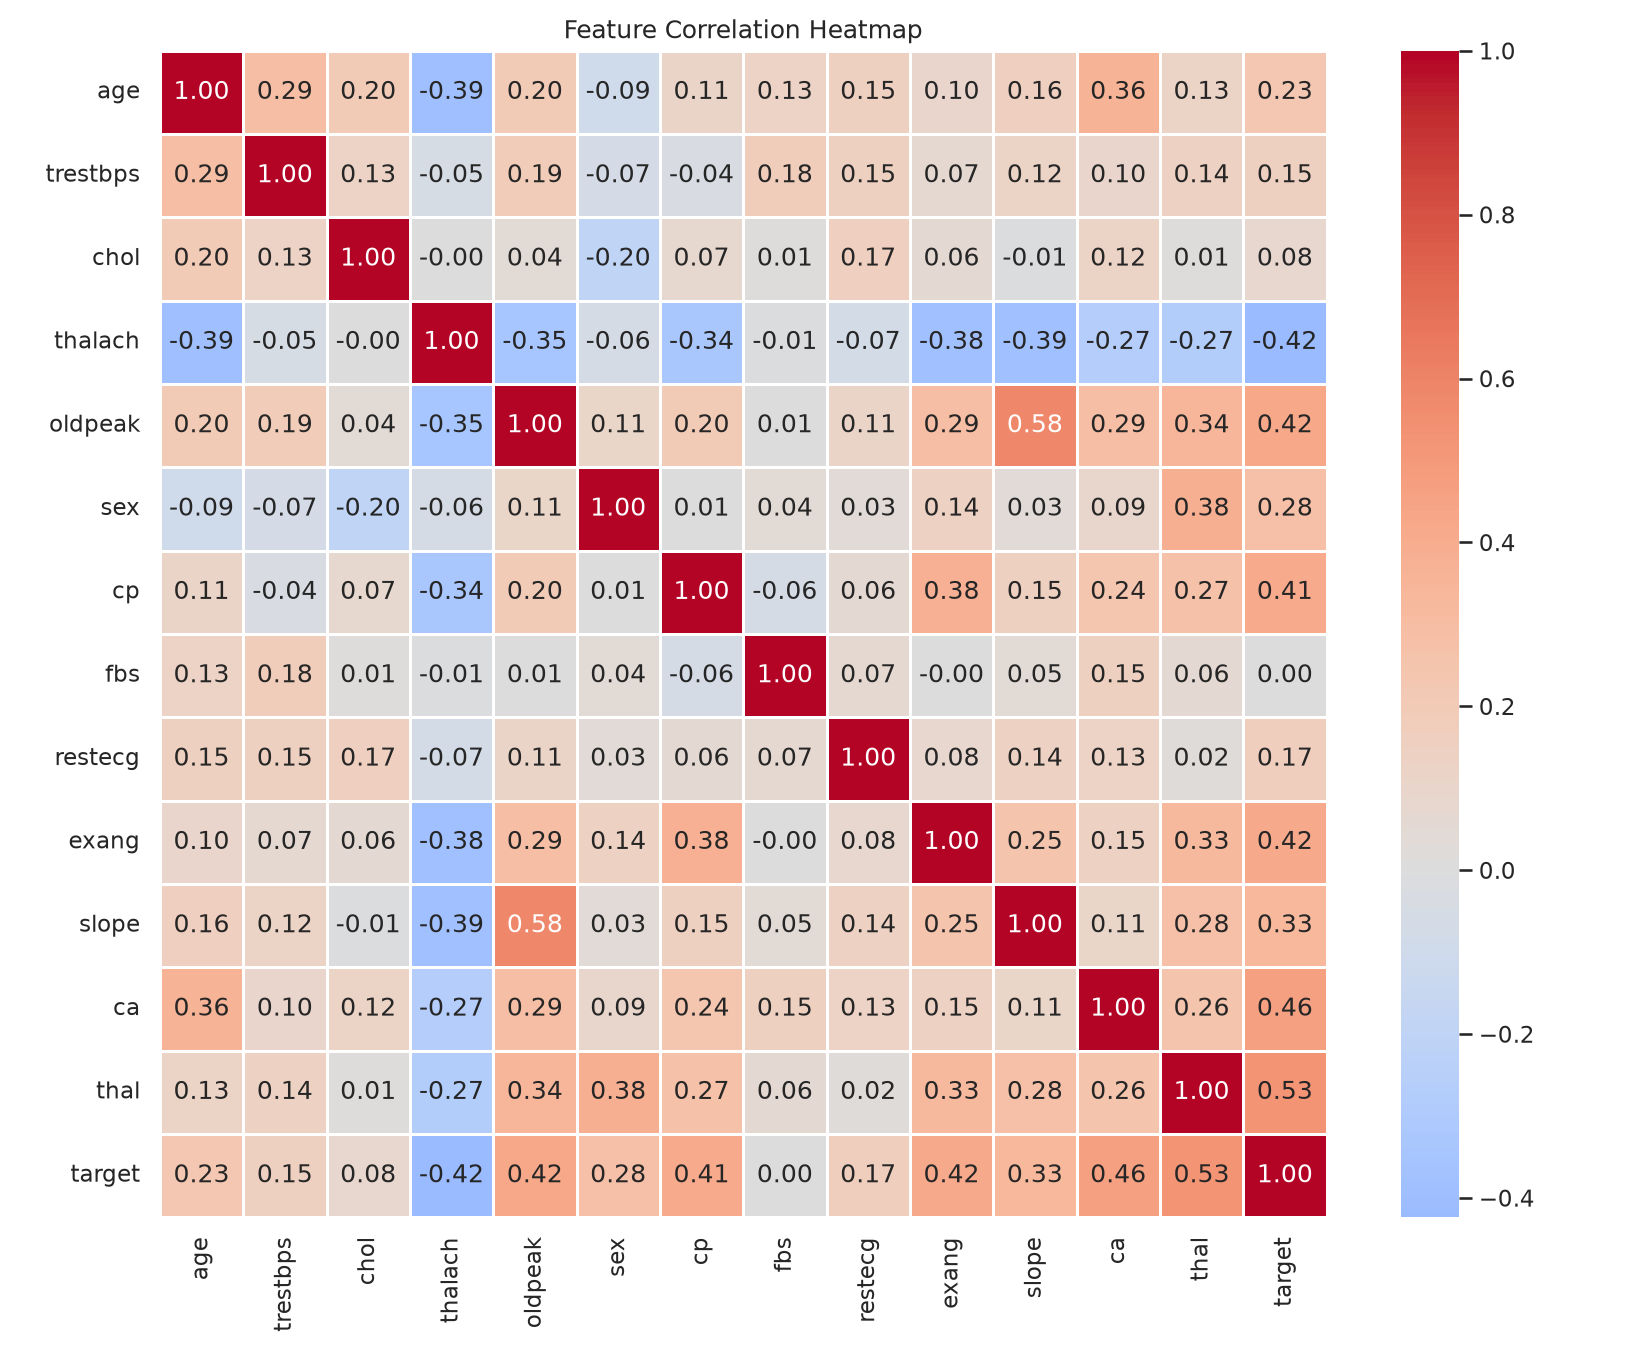

In [7]:
plot_correlation_heatmap(df, FIGURES_DIR)
display(Image(filename=FIGURES_DIR / "correlation_heatmap.png"))

## 7. Feature relationship analysis

A pairplot of the continuous features — pairwise scatter relationships plus per-feature KDE on the diagonal, colored by diagnosis. Complements the correlation heatmap's numeric summary with the actual pairwise shapes.

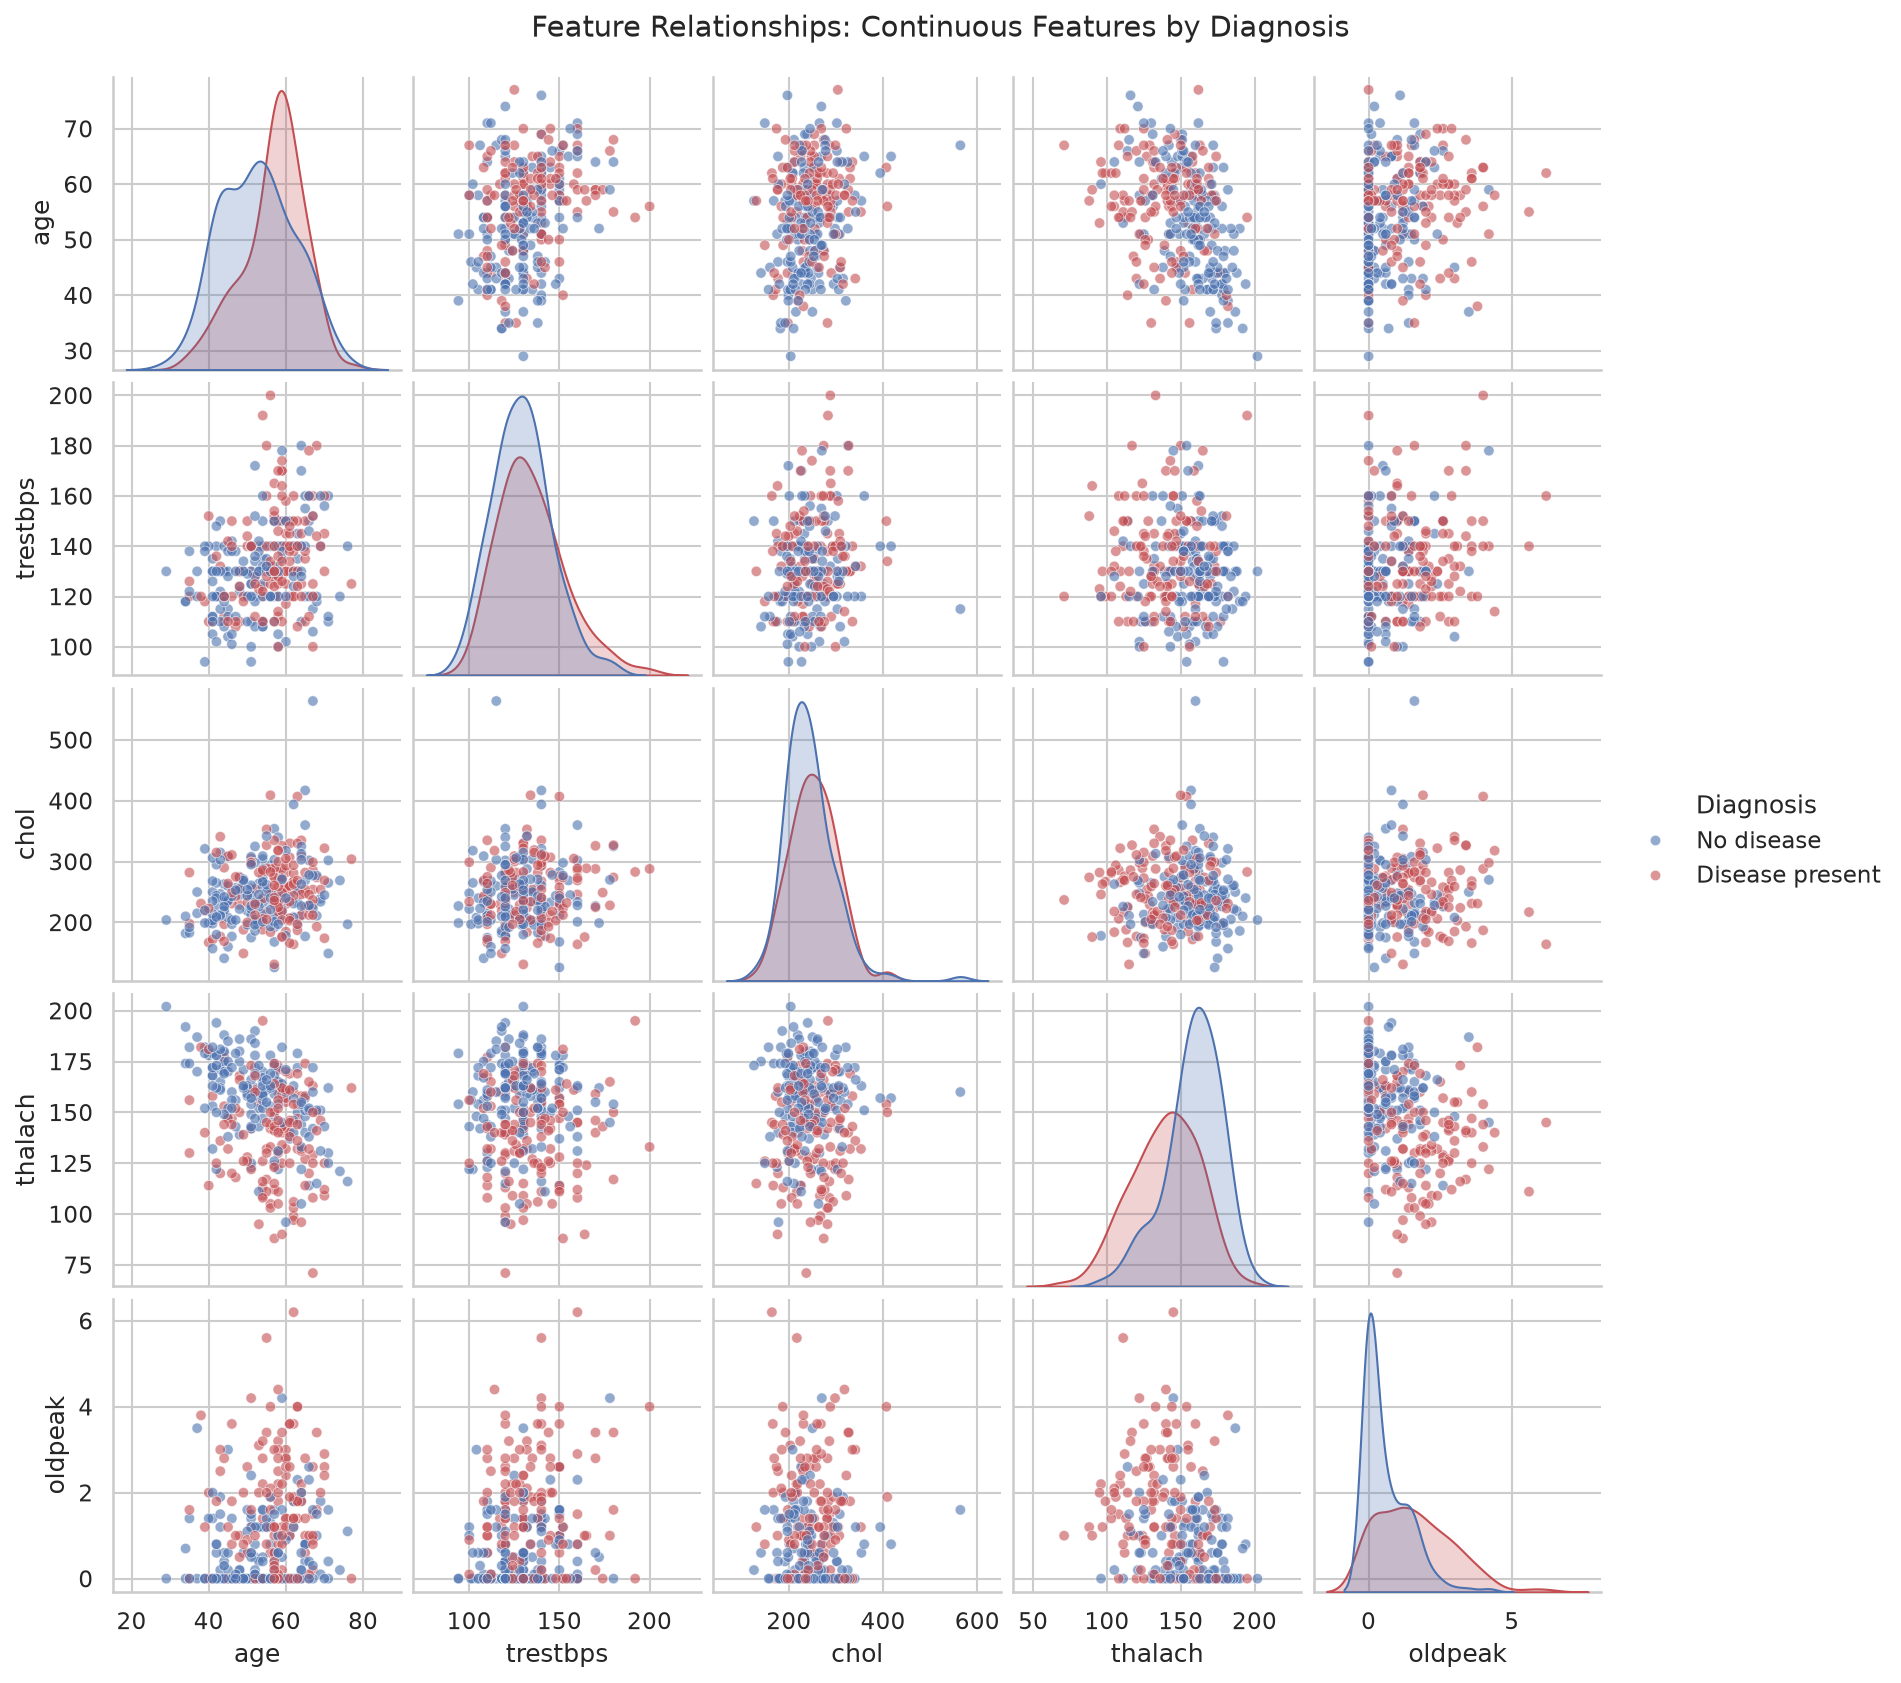

In [8]:
plot_feature_relationships(df, FIGURES_DIR)
display(Image(filename=FIGURES_DIR / "feature_relationships.png"))

`thal`, `ca`, `oldpeak`, `exang`, and `cp` show the strongest linear association with the target — consistent with established clinical risk factors, which is a reasonable sanity check on data quality.

## Next step

Feature engineering, model training, cross-validation, hyperparameter tuning, and MLflow tracking are covered in `02_training.ipynb`.